In [2]:
import pandas as pd
# ============================================================
# ÉTAPE 3 — CRÉATION DE LA VARIABLE CIBLE (LABELING)
# ============================================================

df_clean_capped = pd.read_csv('../data/processed/cleaned_data.csv')
df_labeled = df_clean_capped.copy()

# Plages médicales normales (basées sur valeurs de référence standards)
normal_ranges = {
    'ERY':   (4.2, 5.8),
    'HK':    (37, 52),
    'LEUKO': (4.0, 11.0),
    'HB':    (12, 17),
    'PLT':   (150, 400),
    'MCV':   (80, 100),
    'MCHC':  (32, 36),
    'MCH':   (27, 33),
    'RDW':   (11.5, 14.5)
}

# -------------------------
# Score simple (compte d'anomalies)
# -------------------------
df_labeled['anomaly_score'] = 0
for col, (low, high) in normal_ranges.items():
    df_labeled['anomaly_score'] += (
        (df_labeled[col] < low) | (df_labeled[col] > high)
    ).astype(int)

# -------------------------
# Score pondéré (sévérité médicale)
# -------------------------
# Poids : plus le poids est élevé, plus l'anomalie compte
weights = {
    'ERY': 3,
    'HK': 1,
    'LEUKO': 3,
    'HB': 3,
    'PLT': 3,
    'MCV': 1,
    'MCHC': 1,
    'MCH': 1,
    'RDW': 1
}

df_labeled['weighted_score'] = 0
for col, (low, high) in normal_ranges.items():
    is_anomaly = ((df_labeled[col] < low) | (df_labeled[col] > high)).astype(int)
    df_labeled['weighted_score'] += is_anomaly * weights.get(col, 1)

print("Distribution du score d'anomalie (0 à 9):")
print(df_labeled['anomaly_score'].value_counts().sort_index())
print('\nDistribution du score pondéré (weighted_score):')
print(df_labeled['weighted_score'].value_counts().sort_index())

Distribution du score d'anomalie (0 à 9):
anomaly_score
0    105997
1     81352
2     54502
3     66455
4     79311
5     62774
6     42215
7     21877
8      8191
9      1170
Name: count, dtype: int64

Distribution du score pondéré (weighted_score):
weighted_score
0     105997
1      36344
2      12182
3      49618
4      34499
5      16518
6      18386
7      50250
8      50127
9      21868
10     37498
11     36931
12     13730
13     16379
14     13180
15      4550
16      4617
17      1170
Name: count, dtype: int64


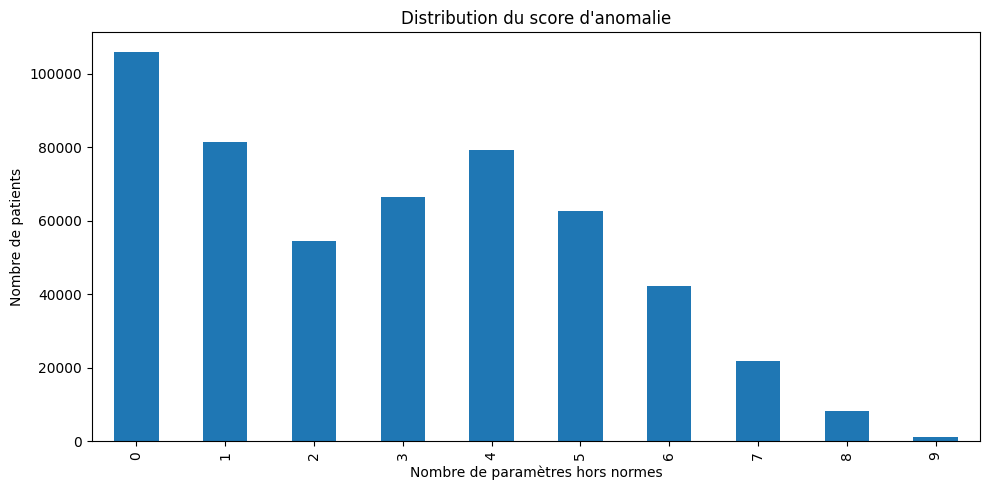

In [ ]:
import matplotlib.pyplot as plt

# Visualiser la distribution du score
plt.figure(figsize=(10, 5))
df_labeled['anomaly_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution du score d\'anomalie')
plt.xlabel('Nombre de paramètres hors normes')
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.savefig('../figures/distribution_anomaly_score.png', dpi=150)
plt.show()

In [6]:
# Tester plusieurs seuils pour le label — IMPORTANT pour le rapport
print("=" * 60)
print("COMPARAISON DES SEUILS POUR LE LABEL")
print("=" * 60)

# 1) Seuils sur le score simple (compte d'anomalies)
print('\n-- Score simple (anomaly_score) --')
for threshold in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
    label_temp = (df_labeled['anomaly_score'] >= threshold).astype(int)
    pct_anomaly = label_temp.mean() * 100
    print(f"Seuil >= {threshold} : "
          f"{label_temp.sum()} anomalies / {len(label_temp)} "
          f"({pct_anomaly:.2f}%) | Normal: {100-pct_anomaly:.2f}%")

# 2) Seuils sur le score pondéré (weighted_score)
print('\n-- Score pondéré (weighted_score) --')
max_w = int(df_labeled['weighted_score'].max())
for threshold in range(1, max_w + 1):
    label_temp = (df_labeled['weighted_score'] >= threshold).astype(int)
    pct_anomaly = label_temp.mean() * 100
    print(f"Seuil >= {threshold} : "
          f"{label_temp.sum()} anomalies / {len(label_temp)} "
          f"({pct_anomaly:.2f}%) | Normal: {100-pct_anomaly:.2f}%")

COMPARAISON DES SEUILS POUR LE LABEL

-- Score simple (anomaly_score) --
Seuil >= 1 : 417847 anomalies / 523844 (79.77%) | Normal: 20.23%
Seuil >= 2 : 336495 anomalies / 523844 (64.24%) | Normal: 35.76%
Seuil >= 3 : 281993 anomalies / 523844 (53.83%) | Normal: 46.17%
Seuil >= 4 : 215538 anomalies / 523844 (41.15%) | Normal: 58.85%
Seuil >= 5 : 136227 anomalies / 523844 (26.01%) | Normal: 73.99%
Seuil >= 6 : 73453 anomalies / 523844 (14.02%) | Normal: 85.98%
Seuil >= 7 : 31238 anomalies / 523844 (5.96%) | Normal: 94.04%
Seuil >= 8 : 9361 anomalies / 523844 (1.79%) | Normal: 98.21%
Seuil >= 9 : 1170 anomalies / 523844 (0.22%) | Normal: 99.78%

-- Score pondéré (weighted_score) --
Seuil >= 1 : 417847 anomalies / 523844 (79.77%) | Normal: 20.23%
Seuil >= 2 : 381503 anomalies / 523844 (72.83%) | Normal: 27.17%
Seuil >= 3 : 369321 anomalies / 523844 (70.50%) | Normal: 29.50%
Seuil >= 4 : 319703 anomalies / 523844 (61.03%) | Normal: 38.97%
Seuil >= 5 : 285204 anomalies / 523844 (54.44%) | Nor

on calcul et on affiche la distribution de weighted score 
on trace l'histogramme
on imprime les proportions par seuil
on propose des seuils donnant 10–30% d'anomalies


Distribution du weighted_score:
weighted_score
0     105997
1      36344
2      12182
3      49618
4      34499
5      16518
6      18386
7      50250
8      50127
9      21868
10     37498
11     36931
12     13730
13     16379
14     13180
15      4550
16      4617
17      1170
Name: count, dtype: int64


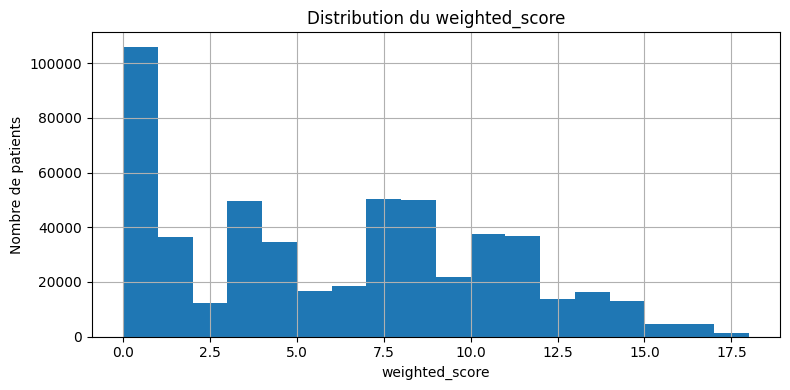


Proportions par seuil (weighted_score):
Seuil >= 1 : 417847 anomalies / 523844 (79.77%)
Seuil >= 2 : 381503 anomalies / 523844 (72.83%)
Seuil >= 3 : 369321 anomalies / 523844 (70.50%)
Seuil >= 4 : 319703 anomalies / 523844 (61.03%)
Seuil >= 5 : 285204 anomalies / 523844 (54.44%)
Seuil >= 6 : 268686 anomalies / 523844 (51.29%)
Seuil >= 7 : 250300 anomalies / 523844 (47.78%)
Seuil >= 8 : 200050 anomalies / 523844 (38.19%)
Seuil >= 9 : 149923 anomalies / 523844 (28.62%)
Seuil >= 10 : 128055 anomalies / 523844 (24.45%)
Seuil >= 11 : 90557 anomalies / 523844 (17.29%)
Seuil >= 12 : 53626 anomalies / 523844 (10.24%)
Seuil >= 13 : 39896 anomalies / 523844 (7.62%)
Seuil >= 14 : 23517 anomalies / 523844 (4.49%)
Seuil >= 15 : 10337 anomalies / 523844 (1.97%)
Seuil >= 16 : 5787 anomalies / 523844 (1.10%)
Seuil >= 17 : 1170 anomalies / 523844 (0.22%)

Thresholds candidates (10-30% anomalies): [(9, np.float64(28.619779934484313)), (10, np.float64(24.445254694145586)), (11, np.float64(17.28701674544

In [7]:
import matplotlib.pyplot as plt

# Analyse détaillée du weighted_score : counts, histogramme et proportions par seuil
print('\nDistribution du weighted_score:')
print(df_labeled['weighted_score'].value_counts().sort_index())
plt.figure(figsize=(8, 4))
df_labeled['weighted_score'].hist(bins=range(int(df_labeled['weighted_score'].max())+2))
plt.title('Distribution du weighted_score')
plt.xlabel('weighted_score')
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.savefig('../figures/distribution_weighted_score.png', dpi=150)
plt.show()

# Proportions d'anomalies pour chaque seuil possible
max_w = int(df_labeled['weighted_score'].max())
print('\nProportions par seuil (weighted_score):')
thresholds = list(range(1, max_w+1))
candidates = []
for thr in thresholds:
    label_temp = (df_labeled['weighted_score'] >= thr).astype(int)
    pct = label_temp.mean() * 100
    print(f'Seuil >= {thr} : {label_temp.sum()} anomalies / {len(label_temp)} ({pct:.2f}%)')
    if 10 <= pct <= 30:
        candidates.append((thr, pct))
if candidates:
    print('\nThresholds candidates (10-30% anomalies):', candidates)
else:
    # proposer le seuil le plus proche de 20% si aucun dans 10-30%
    target = 20.0
    best = None
    best_diff = 1e9
    for thr in thresholds:
        pct = (df_labeled['weighted_score'] >= thr).mean() * 100
        diff = abs(pct - target)
        if diff < best_diff:
            best_diff = diff
            best = (thr, pct)
    print('\nAucun seuil dans 10-30% ; seuil le plus proche de 20% :', best)

In [8]:
THRESHOLD_WEIGHTED = 10

# Appliquer le label pondéré puis afficher la distribution
# Ce bloc doit précéder la visualisation finale ci-dessous
# pour que le dataset contienne bien le label mis à jour.
df_labeled['label'] = (df_labeled['weighted_score'] >= THRESHOLD_WEIGHTED).astype(int)
print(df_labeled['label'].value_counts())
print('Anomalies (1) :', int(df_labeled['label'].sum()))
print('Normaux (0) :', int((df_labeled['label'] == 0).sum()))

label
0    395789
1    128055
Name: count, dtype: int64
Anomalies (1) : 128055
Normaux (0) : 395789


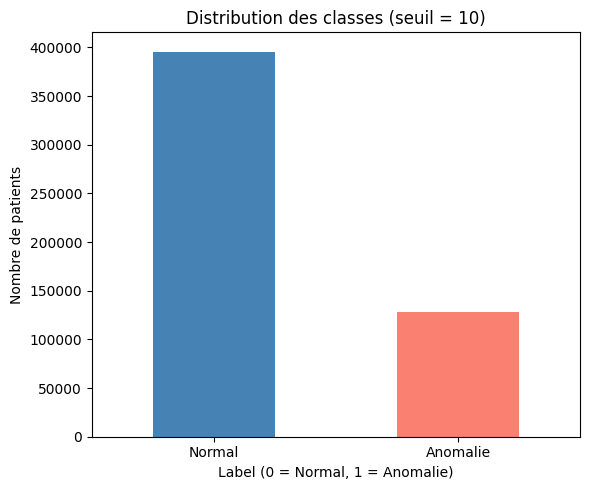

In [9]:
# Visualisation finale de la distribution des classes
plt.figure(figsize=(6, 5))
df_labeled['label'].value_counts().sort_index().plot(kind='bar', color=['steelblue', 'salmon'])

plt.title(f'Distribution des classes (seuil = {THRESHOLD_WEIGHTED})')
plt.xlabel('Label (0 = Normal, 1 = Anomalie)')
plt.ylabel('Nombre de patients')
plt.xticks([0, 1], ['Normal', 'Anomalie'], rotation=0)
plt.tight_layout()
plt.savefig('../figures/distribution_classes.png', dpi=150)
plt.show()

In [10]:
# Sauvegarder le dataset avec labels
df_labeled.to_csv('../data/processed/labeled_data.csv', index=False)
print("Dataset avec labels sauvegardé")
df_labeled.head()

Dataset avec labels sauvegardé


,ERY,HK,LEUKO,HB,PLT,MCV,MCHC,MCH,RDW,anomaly_score,weighted_score,label
0,4.5,40.7,8.5,13.7,154,90.4,33.7,30.4,13.2,0,0,0
1,4.2,36.8,11.8,12.9,255,87.4,35.1,30.6,12.7,2,4,0
2,4.3,37.4,8.5,12.7,310,86.4,33.9,29.3,13.0,0,0,0
3,4.3,36.4,7.7,13.3,221,84.4,36.6,30.9,13.1,2,2,0
4,4.1,37.1,10.8,12.3,198,91.3,33.2,30.3,13.5,1,3,0


In [10]:
print("Étape 3 terminée — Dataset avec labels créé et sauvegardé")

Étape 3 terminée — Dataset avec labels créé et sauvegardé


In [11]:
(df_labeled['weighted_score'] >= 10).mean()*100

np.float64(24.445254694145586)

In [12]:
print(df_labeled['label'].value_counts())

label
0    395789
1    128055
Name: count, dtype: int64
